<a href="https://colab.research.google.com/github/tlsgPqls/test/blob/main/6_1_fashion_mnist_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

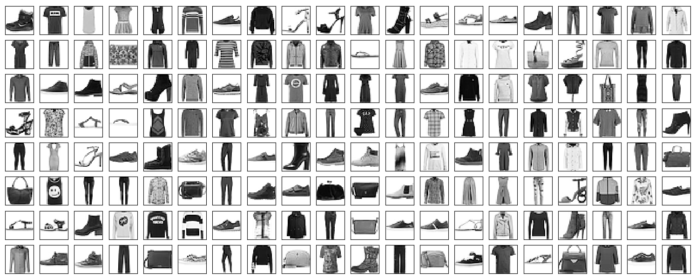


## 데이터 로드

In [48]:
import tensorflow as tf

In [49]:
(x_train,y_train),(x_test,y_test)=\
tf.keras.datasets.fashion_mnist.load_data()

### 데이터 shape 확인

In [50]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [51]:
import matplotlib.pyplot as plt

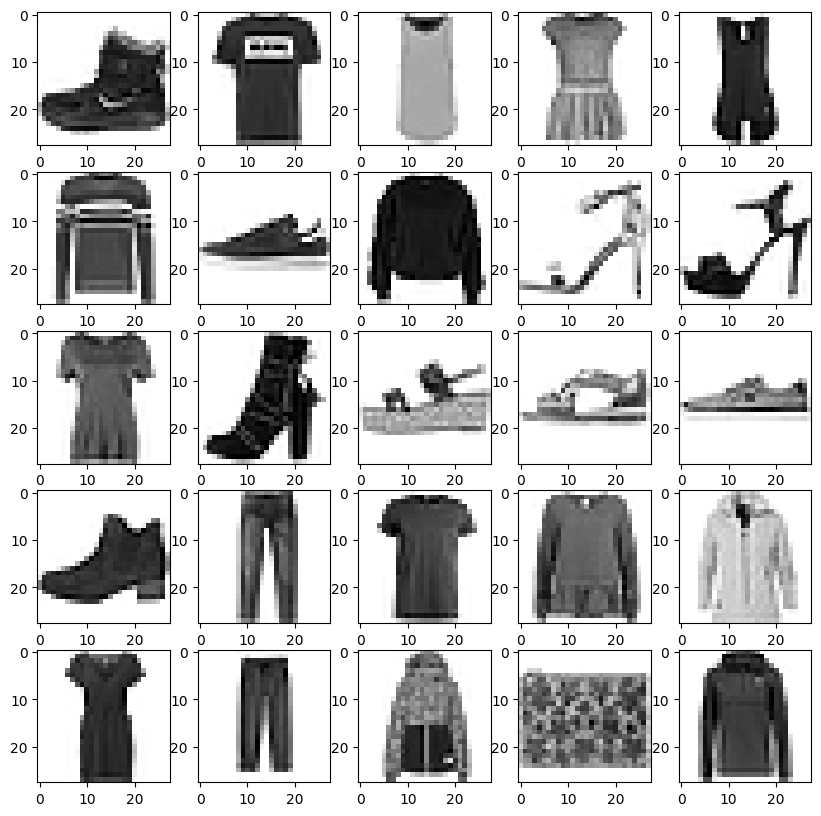

In [52]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [53]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

In [54]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [55]:
print([items[i] for i in y_train[0:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


list 축약 표현

In [56]:
import numpy as np

In [57]:
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [58]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [59]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
x_train, x_val, y_train, y_val=\
train_test_split(x_train,y_train,test_size=0.2,random_state=11)

In [62]:
print(x_train.shape, y_train.shape)
print(x_test.shape,y_test.shape)
print(x_val.shape,y_val.shape)

(48000, 28, 28) (48000,)
(10000, 28, 28) (10000,)
(12000, 28, 28) (12000,)


60000개에서 더 쪼갠것 // y들을 one-hot encoding으로 바꿔줌

## one-hot encoding

In [63]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val = tf.keras.utils.to_categorical(y_val,num_classes=10)
y_test=tf.keras.utils.to_categorical(y_test,num_classes=10)

In [64]:
print(y_train.shape,y_val.shape, y_test.shape)

(48000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [65]:
x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

In [66]:
print(x_val[0:10])

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


## 직렬화

In [67]:
x_train = x_train.reshape(-1,28*28)
x_val = x_val.reshape(-1,28*28)
x_test=x_test.reshape(-1*28*28)

In [68]:
print(x_train.shape,x_val.shape,x_test.shape)

(48000, 784) (12000, 784) (7840000,)


## model 생성

In [69]:
from tensorflow.keras import layers, models

In [70]:
784-128-64-32-10

550

In [71]:
model=models.Sequential([
    layers.Dense(128, activation='sigmoid',input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(loss='categorical_crossentropy', metrics=['acc'])

## 학습

In [74]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.7932 - loss: 0.5779 - val_acc: 0.8379 - val_loss: 0.4482
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8478 - loss: 0.4150 - val_acc: 0.8570 - val_loss: 0.3986
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8609 - loss: 0.3762 - val_acc: 0.8603 - val_loss: 0.3932
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8713 - loss: 0.3485 - val_acc: 0.8607 - val_loss: 0.3804
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8786 - loss: 0.3308 - val_acc: 0.8791 - val_loss: 0.3501
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8843 - loss: 0.3146 - val_acc: 0.8783 - val_loss: 0.3411
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.8892 - loss: 0.3038 - val_acc: 0.8711 - val_loss: 0.3665
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.8917 - loss: 0.2938 - val_acc: 0.8823 - val_loss: 0.3317
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━

## 학습곡선

In [75]:
history.history

{'acc': [0.7931874990463257,
  0.8478333353996277,
  0.8608541488647461,
  0.8712916374206543,
  0.8785625100135803,
  0.8843125104904175,
  0.8891875147819519,
  0.8917083144187927,
  0.8957916498184204,
  0.8979374766349792,
  0.9010000228881836,
  0.9041249752044678,
  0.9044791460037231,
  0.9051458239555359,
  0.9072499871253967,
  0.9083958268165588,
  0.9116041660308838,
  0.9127083420753479,
  0.913812518119812,
  0.9151874780654907,
  0.9155208468437195,
  0.9162083268165588,
  0.917312502861023,
  0.9192500114440918,
  0.9196249842643738,
  0.9216041564941406,
  0.9208333492279053,
  0.9228749871253967,
  0.9230208396911621,
  0.9249791502952576],
 'loss': [0.5779468417167664,
  0.41497108340263367,
  0.3761761486530304,
  0.3484727442264557,
  0.33075186610221863,
  0.3146032989025116,
  0.3038466274738312,
  0.2937827408313751,
  0.28456586599349976,
  0.2789213955402374,
  0.2704490125179291,
  0.26555168628692627,
  0.2592824399471283,
  0.25381553173065186,
  0.250985771

학습된걸 보여줌 - 러닝커브

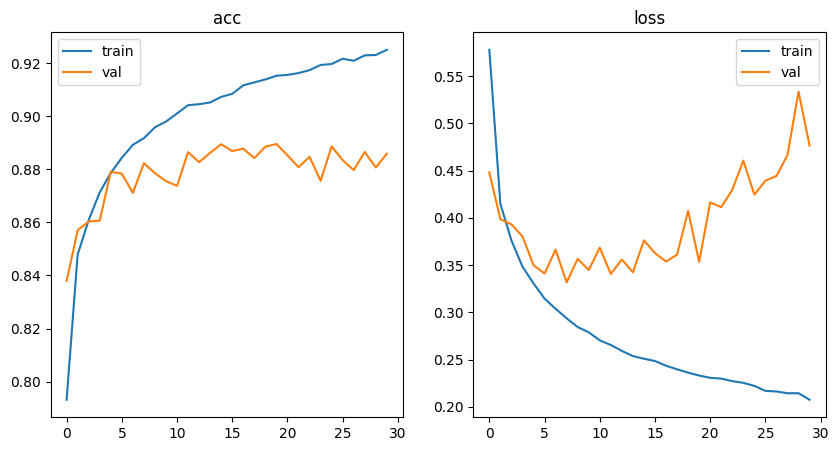

In [76]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train','val'])
plt.title('acc')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.title('loss')
plt.show()

weight 가 줄어드니까 방향이 바뀜 / 사실 줄어드는게 문제임
/ 발산을 하지않음

## 과대적합(Over fitting)/과소적합(Under fitting)

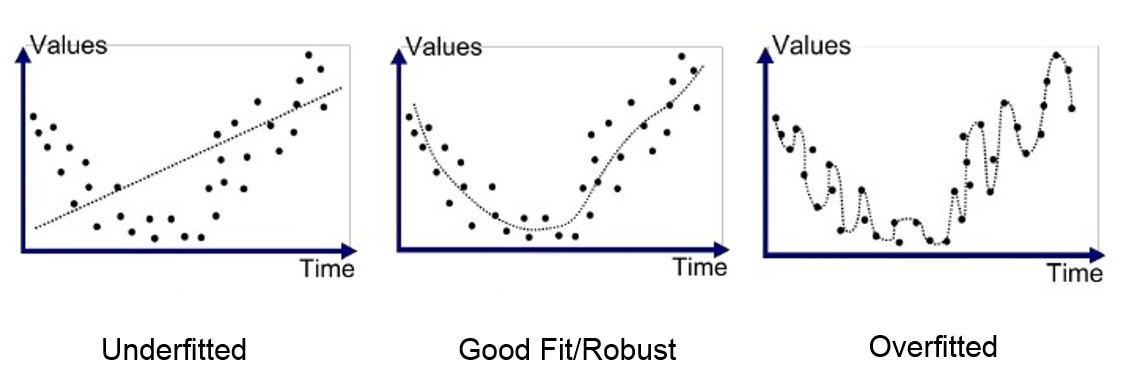

학습이 덜된 그래프/ 적합한 그래프/ 학습이 과한 그래프 (실제데이터와 맞지않을 가능성이 큼)

덴스층???
새로운 데이터를 집어넣으면 잘안됌 끊어버림(드롭아웃)
없애버리면 훨씬 더 잘됌

In [77]:
model1=models.Sequential([
    layers.Dense(128, activation='sigmoid',input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [78]:
model1.compile(loss='categorical_crossentropy', metrics=['acc'])

In [79]:
history1=model1.fit(x_train,y_train,epochs=30,validation_data=(x_val,y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.7685 - loss: 0.6333 - val_acc: 0.8227 - val_loss: 0.4715
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - acc: 0.8326 - loss: 0.4555 - val_acc: 0.8549 - val_loss: 0.4002
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8476 - loss: 0.4198 - val_acc: 0.8594 - val_loss: 0.3878
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8551 - loss: 0.3950 - val_acc: 0.8717 - val_loss: 0.3633
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8612 - loss: 0.3809 - val_acc: 0.8717 - val_loss: 0.3622
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8658 - loss: 0.3697 - val_acc: 0.8755 - val_loss: 0.3426
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8713 - loss: 0.3599 - val_acc: 0.8763 - val_loss: 0.3499
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8706 - loss: 0.3567 - val_acc: 0.8788 - val_loss: 0.3386
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━

오버피팅을 막아주는 일반적인 data 에 맞는 피팅이 좋은것이다

In [80]:
history1.history

{'acc': [0.7684583067893982,
  0.832604169845581,
  0.8476041555404663,
  0.8551250100135803,
  0.8612499833106995,
  0.8658333420753479,
  0.8713333606719971,
  0.8705833554267883,
  0.8737291693687439,
  0.8775625228881836,
  0.8762500286102295,
  0.877958357334137,
  0.8799791932106018,
  0.8814166784286499,
  0.879479169845581,
  0.8808333277702332,
  0.8838958144187927,
  0.883145809173584,
  0.883104145526886,
  0.8846874833106995,
  0.8851666450500488,
  0.885937511920929,
  0.8865000009536743,
  0.887416660785675,
  0.8872291445732117,
  0.8888124823570251,
  0.8887083530426025,
  0.89083331823349,
  0.8899999856948853,
  0.8913750052452087],
 'loss': [0.6332820653915405,
  0.45554882287979126,
  0.4197962284088135,
  0.3949621617794037,
  0.38086748123168945,
  0.3697226643562317,
  0.3598547875881195,
  0.3566923141479492,
  0.35242119431495667,
  0.3456815183162689,
  0.34780603647232056,
  0.34485143423080444,
  0.34367266297340393,
  0.33845609426498413,
  0.34201303124427

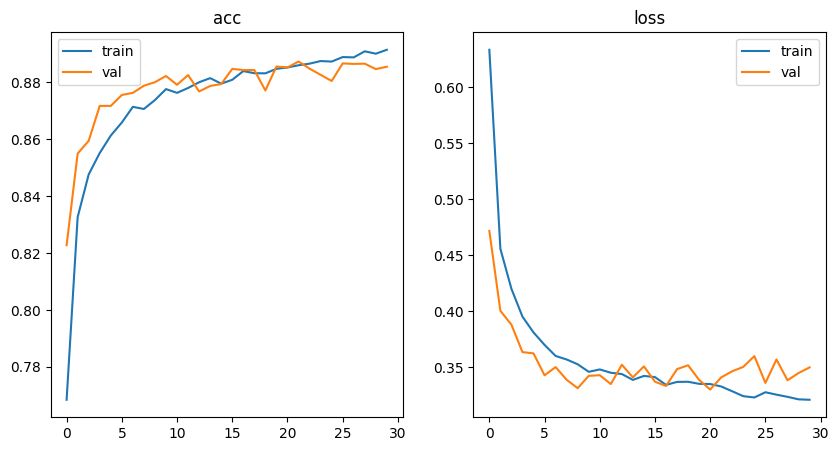

In [81]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.legend(['train','val'])
plt.title('acc')

plt.subplot(1,2,2)
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['train','val'])
plt.title('loss')
plt.show()

In [85]:
x_test = x_test.reshape(-1, 784)

# 이제 다시 평가 실행
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8771 - loss: 0.3812


[0.38121530413627625, 0.8770999908447266]

In [86]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8726 - loss: 0.5080


[0.5080096125602722, 0.8726000189781189]

Model save - weight 저장

In [87]:
model.save('fmnist_nn.h5')

In [88]:
model3 = models.load_model('fmnist_nn.h5')

In [89]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,148 (434.18 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)